Testing splicing and correciton of SIMBA at different reference heights

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import cmocean
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%m-%d')
import glob

from ICECAPS_support_functions import *

import csv
import datetime
from datetime import datetime as dt

from cmcrameri import cm as cmr

In [6]:
simba_filepath = '/psd3data/arctic/sledd/Raven_simba/corrections_by_height/'

In [9]:
varnames = ['temperature','initial_height','time']
splice_corrections = {}

for h in range(0,39,2):
    simba_fname = f'firnprofile-combined-corrected-at{h}.sled.level2.beta.15min.20240517-20240821_created_September_11_2025.nc'
    season_data = {}
    varnames = ['temperature','temperature_correction','initial_height','time']
    fdic = load_netcdf(simba_filepath+simba_fname, varnames)
    
    fstart_time = dt.strptime(fdic['time_unit'], 'minutes since %Y-%m-%d')
    
    fdic['dates'] = np.asarray([fstart_time+datetime.timedelta(minutes=int(m)) for m in fdic['time']])
    
    for var in ['temperature','dates','initial_height','temperature_correction']:
        season_data[var] = fdic[var]

    splice_corrections[h] = season_data

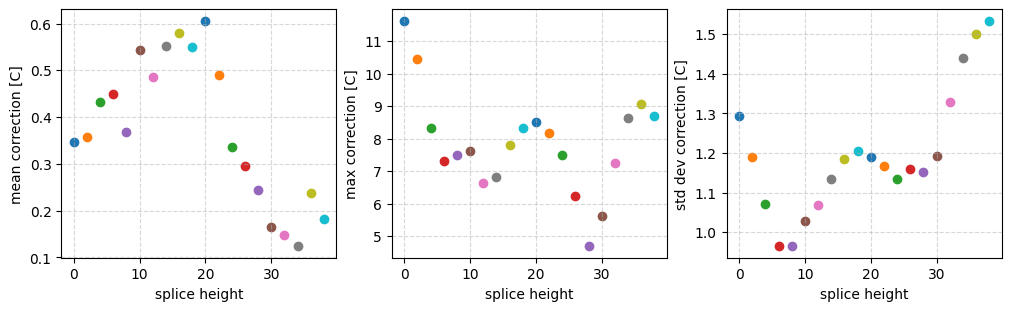

In [19]:
fig, axs = plt.subplots(1,3, figsize=(10,3), constrained_layout=True)

for h in range(0,39,2):
    splice_correction = np.ma.masked_invalid(splice_corrections[h]['temperature_correction'])
    
    splice_stats = [splice_correction.mean(), splice_correction.max(), splice_correction.std()]
    for i, ax in enumerate(axs.ravel()):
        ax.scatter(h, splice_stats[i])

ylabels = ['mean', 'max', 'std dev']
for i, ax in enumerate(axs.ravel()):
    ax.set_xlabel('splice height')
    ax.set_ylabel(f'{ylabels[i]} correction [C]')
    ax.grid(alpha=.5, ls='--')

plt.show()

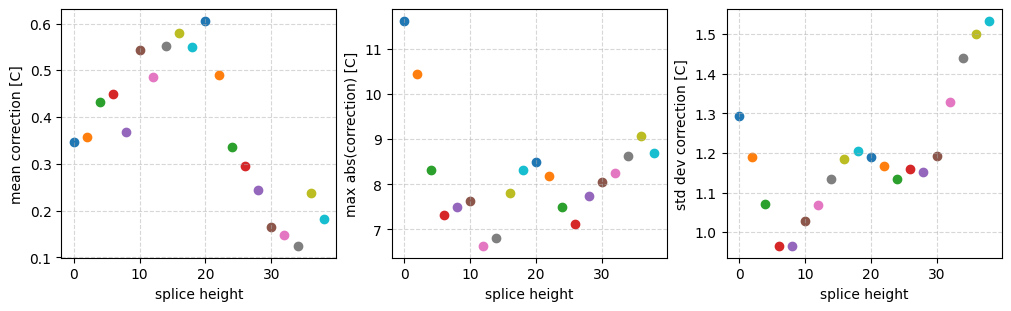

In [20]:
fig, axs = plt.subplots(1,3, figsize=(10,3), constrained_layout=True)

for h in range(0,39,2):
    splice_correction = np.ma.masked_invalid(splice_corrections[h]['temperature_correction'])
    
    splice_stats = [splice_correction.mean(), abs(splice_correction).max(), splice_correction.std()]
    for i, ax in enumerate(axs.ravel()):
        ax.scatter(h, splice_stats[i])

ylabels = ['mean correction', 'max abs(correction)', 'std dev correction']
for i, ax in enumerate(axs.ravel()):
    ax.set_xlabel('splice height')
    ax.set_ylabel(f'{ylabels[i]} [C]')
    ax.grid(alpha=.5, ls='--')

plt.show()

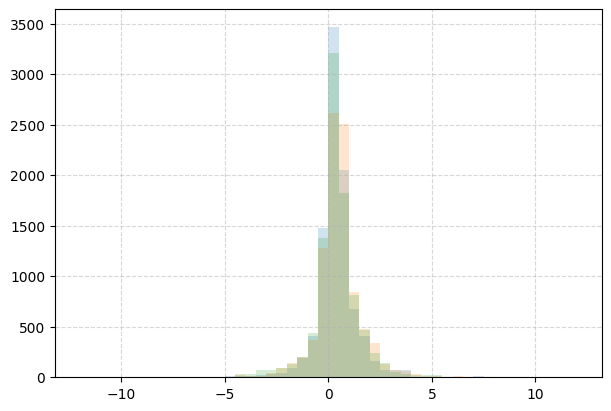

In [28]:
fig, ax = plt.subplots(1, figsize=(6,4), constrained_layout=True)

for h in [8,12, 24]:
    splice_correction = np.ma.masked_invalid(splice_corrections[h]['temperature_correction'])
    
    ax.hist(splice_correction[~splice_correction.mask], bins=np.arange(-12,12.1,.5), alpha=.2)

ax.grid(alpha=.5, ls='--')
plt.show()

Compare surface detection (and maybe solar correction?) for 8, 12, 24, 28?